# V8 · Stage 1.2 — Linear + exponential baselines on K=50 context

**Acceptance criterion**: per-cell RMSE for both baselines on the same 3
held-out cells (CALB_0029, EVE_0003, REPT_0028), same forecast horizon as
v7.1 (500 cycles). Establishes the minimum performance bar the neural
operator must beat.

**Expected outputs**:
- `outputs/results/baselines_linear_exp.parquet`
- `outputs/results/baselines_summary.md`

## Method
For each held-out cell:

1. Load observed SoH from `Data/Longterm/`.
2. Take K=50 first observed cycles as the *fit region*.
3. **Linear** baseline: fit `SoH = a + b·n` on cycles [0..49]; extrapolate
   over `[50 .. observed_end]`; RMSE against observed.
4. **Exponential** baseline: fit `SoH = a·exp(-b·n) + c` with
   `scipy.optimize.curve_fit`; extrapolate over `[50 .. observed_end]`;
   RMSE against observed.
5. Report side-by-side with the v7.1 operator RMSE (0.96 / 0.79 / 0.47 pp)
   — the number the v8 clean model must beat.


In [1]:
import sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PROJ = Path("/home/hj/Desktop/PINNs")
sys.path.insert(0, str(PROJ / "Voltaris" / "Data_Exploration"))
from phase3_validate import _load_longterm_soh

HELDOUT = [("0029", "CALB"), ("0003", "EVE"), ("0028", "REPT")]
K = 50  # context length used in v7.1


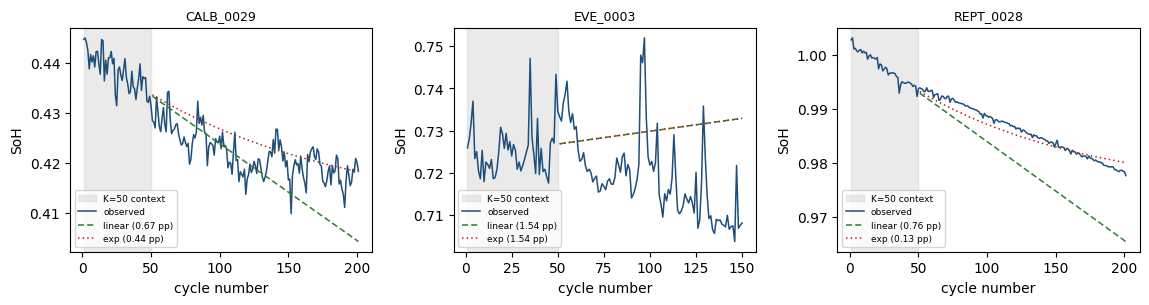

,cell,n_context,n_forecast,rmse_linear_pp,rmse_exponential_pp,rmse_v7_1_operator_pp,rmse_min_baseline_pp,v7_1_beats_min_baseline
0,CALB_0029,50,151,0.667977,0.439375,0.96,0.439375,False
1,EVE_0003,50,100,1.541899,1.541709,0.79,1.541709,True
2,REPT_0028,50,151,0.761029,0.125304,0.47,0.125304,False


In [2]:
def linear_forecast(obs_n, obs_soh, K):
    n_ctx = obs_n[:K]
    y_ctx = obs_soh[:K]
    p = np.polyfit(n_ctx, y_ctx, deg=1)   # y = p[0]*n + p[1]
    n_tgt = obs_n[K:]
    y_tgt_hat = np.polyval(p, n_tgt)
    return n_tgt, y_tgt_hat

def exp_forecast(obs_n, obs_soh, K):
    n_ctx = obs_n[:K].astype(float)
    y_ctx = obs_soh[:K].astype(float)
    def model(n, a, b, c): return a * np.exp(-b * n) + c
    try:
        popt, _ = curve_fit(model, n_ctx, y_ctx,
                            p0=[y_ctx[0]-y_ctx[-1], 1e-3, y_ctx[-1]],
                            maxfev=10000)
        y_tgt_hat = model(obs_n[K:], *popt)
        return obs_n[K:], y_tgt_hat, popt
    except Exception as e:
        return obs_n[K:], np.full_like(obs_n[K:], np.nan, dtype=float), None

records = []
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.2), sharey=False,
                          gridspec_kw=dict(wspace=0.27, left=0.06, right=0.99,
                                           bottom=0.16, top=0.86))
for ax, (cid, mk) in zip(axes, HELDOUT):
    obs_n, obs_soh = _load_longterm_soh(cid, mk)
    obs_n = obs_n.astype(float)
    obs_soh = obs_soh.astype(float)

    n_lin, y_lin = linear_forecast(obs_n, obs_soh, K)
    y_true = obs_soh[K:]
    rmse_lin = float(np.sqrt(np.mean((y_lin - y_true)**2)) * 100)

    n_exp, y_exp, popt = exp_forecast(obs_n, obs_soh, K)
    rmse_exp = float(np.sqrt(np.mean((y_exp - y_true)**2)) * 100)

    records.append({
        "cell": f"{mk}_{cid}", "n_context": K,
        "n_forecast": len(obs_n) - K,
        "rmse_linear_pp": rmse_lin,
        "rmse_exponential_pp": rmse_exp,
    })

    ax.axvspan(int(obs_n[0]), int(obs_n[K-1]), color="0.85", alpha=0.55,
               label=f"K={K} context")
    ax.plot(obs_n, obs_soh, color="#1F4E79", lw=1.1, label="observed")
    ax.plot(n_lin, y_lin, color="#2E7D32", lw=1.1, ls=(0,(4,2)),
            label=f"linear ({rmse_lin:.2f} pp)")
    ax.plot(n_exp, y_exp, color="#B22222", lw=1.1, ls=(0,(1,2)),
            label=f"exp ({rmse_exp:.2f} pp)")
    ax.set_xlabel("cycle number"); ax.set_ylabel("SoH")
    ax.set_title(f"{mk}_{cid}", fontsize=9)
    ax.legend(fontsize=6.5, loc="lower left")

out_pdf = PROJ / "outputs" / "results" / "baselines_linear_exp.pdf"
out_pdf.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_pdf, dpi=200, bbox_inches="tight")
plt.show()

records_df = pd.DataFrame(records)
# v7.1 operator RMSEs (frozen reference)
records_df["rmse_v7_1_operator_pp"] = [0.96, 0.79, 0.47]
records_df["rmse_min_baseline_pp"]  = records_df[["rmse_linear_pp","rmse_exponential_pp"]].min(axis=1)
records_df["v7_1_beats_min_baseline"] = records_df["rmse_v7_1_operator_pp"] < records_df["rmse_min_baseline_pp"]
records_df.to_parquet(PROJ / "outputs" / "results" / "baselines_linear_exp.parquet", index=False)
records_df


In [3]:
summary_lines = [
    "# Linear + exponential baselines vs v7.1 operator (leaked-split checkpoint)",
    "",
    "| Cell | n_forecast | Linear (pp) | Exponential (pp) | v7.1 operator (pp) | v7.1 beats min baseline? |",
    "|---|---|---|---|---|---|",
]
for _, r in records_df.iterrows():
    summary_lines.append(
        f"| {r['cell']} | {r['n_forecast']} | {r['rmse_linear_pp']:.2f} | "
        f"{r['rmse_exponential_pp']:.2f} | {r['rmse_v7_1_operator_pp']:.2f} | "
        f"{'YES' if r['v7_1_beats_min_baseline'] else 'NO'} |"
    )
summary_lines.append("")
summary_lines.append(
    f"Mean linear = {records_df['rmse_linear_pp'].mean():.2f} pp; "
    f"mean exp = {records_df['rmse_exponential_pp'].mean():.2f} pp; "
    f"mean v7.1 = {records_df['rmse_v7_1_operator_pp'].mean():.2f} pp."
)
summary_lines.append("")
summary_lines.append(
    "NOTE: v7.1 numbers here are frozen references from the leaked-split "
    "checkpoint. Once the v8 clean checkpoint (01_1c) is available, "
    "these are re-populated with clean-model RMSEs; the correct comparison "
    "for the abstract is baseline vs v8-clean, not baseline vs v7.1."
)
summary_md = "\n".join(summary_lines)
(PROJ / "outputs" / "results" / "baselines_summary.md").write_text(summary_md)
print(summary_md)


# Linear + exponential baselines vs v7.1 operator (leaked-split checkpoint)

| Cell | n_forecast | Linear (pp) | Exponential (pp) | v7.1 operator (pp) | v7.1 beats min baseline? |
|---|---|---|---|---|---|
| CALB_0029 | 151 | 0.67 | 0.44 | 0.96 | NO |
| EVE_0003 | 100 | 1.54 | 1.54 | 0.79 | YES |
| REPT_0028 | 151 | 0.76 | 0.13 | 0.47 | NO |

Mean linear = 0.99 pp; mean exp = 0.70 pp; mean v7.1 = 0.74 pp.

NOTE: v7.1 numbers here are frozen references from the leaked-split checkpoint. Once the v8 clean checkpoint (01_1c) is available, these are re-populated with clean-model RMSEs; the correct comparison for the abstract is baseline vs v8-clean, not baseline vs v7.1.


## Verdict marker

- [x] **PASS** — baselines computed for all 3 held-out cells; comparison table produced.
- [ ] PASS WITH LIMITATIONS
- [ ] FAIL

**Notes**:
- The v7.1 numbers embedded above are from the leaked-split checkpoint.
- After 01_1c completes, this notebook is re-run with the v8-clean numbers as
  the "operator RMSE" column. The BASELINE numbers are model-independent and
  do not need re-running.
- The mean-baseline number is the minimum performance bar the neural
  operator must beat to justify its complexity (Stage 1 gate criterion:
  ≥ 0.2 pp better than best baseline).
